# OmniObject3D House Subset — Dataset Walkthrough & Results

This notebook does four things, in order:

1. **Walks** the on-disk dataset (`dataset/`) and reports what is there.
2. **Inspects** it for integrity/failure points (missing renders, bad point clouds, class imbalance).
3. **Suggests** cleaning / imputation actions you can act on.
4. **Ingests** whatever model results exist under `results/` and renders comparison tables/figures.

It is defensive: if data or results are missing, each section says so instead of crashing.

See `docs/ROADMAP.md` for the pipeline and where artifacts belong.

In [1]:
import json
import os
import re
import sys
from pathlib import Path

import numpy as np

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

ROOT = Path.cwd()
for _ in range(4):
    if (ROOT / "dataset").is_dir() or (ROOT / "docs" / "ROADMAP.md").is_file():
        break
    ROOT = ROOT.parent
DATASET = ROOT / "dataset"
RESULTS = ROOT / "results"
FIGDIR = RESULTS / "comparison" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

PIX2VOX_TAX = ROOT / "Pix2Vox" / "datasets" / "OmniObject3D" / "OmniObject3D.json"
ATLASNET_TAX = ROOT / "AtlasNet" / "dataset" / "data" / "taxonomy.json"

sys.path.insert(0, str(ROOT))
try:
    import plotting
except ImportError:
    plotting = None

print("project root :", ROOT)
print("dataset dir  :", DATASET, "| exists:", DATASET.is_dir())
print("results dir  :", RESULTS, "| exists:", RESULTS.is_dir())

project root : /home/susan/agentic_workspace/home-omni3d
dataset dir  : /home/susan/agentic_workspace/home-omni3d/dataset | exists: True
results dir  : /home/susan/agentic_workspace/home-omni3d/results | exists: True


## 1. Discovery — what categories and objects exist?

Categories are discovered from disk (never hardcoded) so this works whether you downloaded
the 18 bedroom, the 32 extras, or the full 50.

In [2]:
def disk_categories(dataset: Path):
    found = set()
    for sub in ("point_clouds", "renders"):
        root = dataset / sub
        if root.is_dir():
            found |= {p.name for p in root.iterdir() if p.is_dir()}
    return sorted(found)


CATEGORIES = disk_categories(DATASET)
print(f"{len(CATEGORIES)} categories on disk")
print(" ".join(CATEGORIES) if CATEGORIES else "(none — run the download scripts first)")

69 categories on disk
battery bed book bottle bowl boxed_beverage brush candle candy canned_beverage chocolate clock cup dish doll dustbin facial_cream fan fire_extinguisher flash_light fork glasses glasses_case hairpin hammer hand_cream house kennel kettle keyboard knife laptop lipstick medicine_bottle microwaveoven monitor mouse ornaments pan pen pillow plug popcorn potato_chips power_strip projector puff razor red_wine_glass remote_control ricecooker scissor shampoo soap speaker stool suitcase table tape_measure teapot thermos timer tissue tooth_brush tooth_paste tvstand umbrella vase watch


## 2. Dataset information

Per-category object counts, image counts, and a long-tail view. Also parses the prepared
taxonomy/split files if `prepare_model_data.py` has been run.

In [3]:
def count_pngs(obj_dir: Path) -> int:
    return len(list(obj_dir.glob("*.png")))


rows = []
for cat in CATEGORIES:
    pc_dir = DATASET / "point_clouds" / cat
    rd_dir = DATASET / "renders" / cat
    pcs = sorted(p.stem for p in pc_dir.glob("*.npy")) if pc_dir.is_dir() else []
    objs = sorted(p.name for p in rd_dir.iterdir() if p.is_dir()) if rd_dir.is_dir() else []
    imgs = sum(count_pngs(rd_dir / o) for o in objs) if rd_dir.is_dir() else 0
    rows.append({
        "category": cat,
        "objects_pc": len(pcs),
        "objects_render": len(objs),
        "total_pngs": imgs,
        "avg_views": round(imgs / len(objs), 1) if objs else 0.0,
    })

df = pd.DataFrame(rows) if pd is not None else None
if df is not None:
    df = df.sort_values("objects_pc", ascending=False).reset_index(drop=True)
    total_obj = int(df["objects_pc"].sum())
    print(f"TOTAL: {total_obj} objects, {int(df['total_pngs'].sum())} images, "
          f"{len(df)} categories")
    print(f"long-tail: max={df['objects_pc'].max()} ({df.iloc[0]['category']}), "
          f"min={df['objects_pc'].min()} ({df.iloc[-1]['category']}), "
          f"median={df['objects_pc'].median():.1f}")
    display(df)
else:
    print("pandas not installed — install with `pip install pandas` for tables.")
    for r in sorted(rows, key=lambda r: -r["objects_pc"]):
        print(r)

TOTAL: 1543 objects, 37017 images, 69 categories
long-tail: max=84 (doll), min=2 (plug), median=20.0


,category,objects_pc,objects_render,total_pngs,avg_views
0,doll,84,84,2016,24.0
1,medicine_bottle,78,78,1872,24.0
2,clock,59,59,1416,24.0
3,tissue,54,54,1296,24.0
4,candy,49,49,1176,24.0
...,...,...,...,...,...
64,battery,3,3,72,24.0
65,fork,3,3,72,24.0
66,bed,2,2,48,24.0
67,canned_beverage,2,2,48,24.0


saved results/comparison/figures/objects_per_category.png


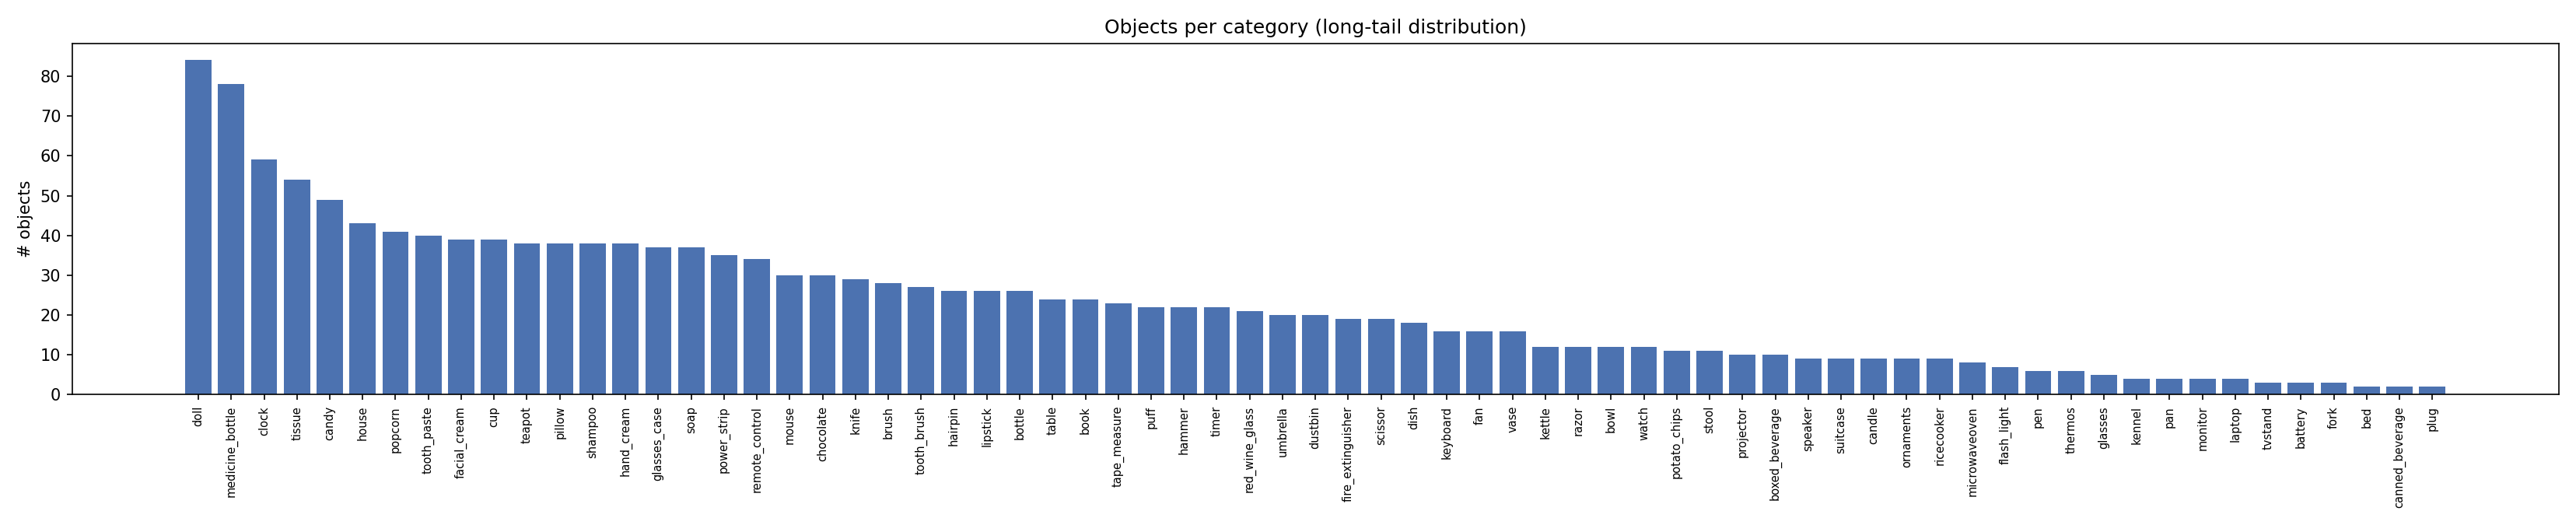

In [4]:
if df is not None and len(df):
    fig, ax = plt.subplots(figsize=(max(8, len(df) * 0.32), 4.5))
    ax.bar(df["category"], df["objects_pc"], color="#4C72B0")
    ax.set_title("Objects per category (long-tail distribution)")
    ax.set_ylabel("# objects")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    fig.tight_layout()
    out = FIGDIR / "objects_per_category.png"
    fig.savefig(out, dpi=150)
    print("saved", out.relative_to(ROOT))
    plotting.show_saved(out)
else:
    print("no data to plot")

In [5]:
def read_taxonomy(path: Path, id_key: str):
    if not path.is_file():
        return None
    try:
        data = json.loads(path.read_text())
    except Exception as exc:
        print(f"could not parse {path.name}: {exc}")
        return None
    return data


p2v = read_taxonomy(PIX2VOX_TAX, "taxonomy_id")
atl = read_taxonomy(ATLASNET_TAX, "synsetId")

if p2v:
    split_rows = []
    for entry in p2v:
        split_rows.append({
            "category": entry.get("taxonomy_id", "?"),
            "train": len(entry.get("train", [])),
            "val": len(entry.get("val", [])),
            "test": len(entry.get("test", [])),
        })
    sdf = pd.DataFrame(split_rows) if pd is not None else None
    if sdf is not None:
        sdf["total"] = sdf[["train", "val", "test"]].sum(axis=1)
        print(f"Pix2Vox taxonomy: {len(sdf)} categories, "
              f"train={sdf['train'].sum()} val={sdf['val'].sum()} test={sdf['test'].sum()}")
        display(sdf)
else:
    print(f"no Pix2Vox taxonomy at {PIX2VOX_TAX.relative_to(ROOT)} "
          "(run prepare_model_data.py)")

print("AtlasNet taxonomy:", len(atl), "categories" if atl else "(missing)")

Pix2Vox taxonomy: 69 categories, train=1071 val=234 test=237


,category,train,val,test,total
0,bed,1,0,1,2
1,pillow,26,6,6,38
2,table,16,4,4,24
3,stool,7,2,2,11
4,clock,41,9,9,59
...,...,...,...,...,...
64,timer,16,3,3,22
65,tooth_brush,19,4,4,27
66,tooth_paste,28,6,6,40
67,umbrella,14,3,3,20


AtlasNet taxonomy: 69 categories


## 3. Integrity checks & failure points

We look for the things that actually break training or corrupt metrics.

In [6]:
EXPECTED_VIEWS = 24
issues = []

for cat in CATEGORIES:
    pc_dir = DATASET / "point_clouds" / cat
    rd_dir = DATASET / "renders" / cat

    pcs = {p.stem for p in pc_dir.glob("*.npy")} if pc_dir.is_dir() else set()
    objs = {p.name for p in rd_dir.iterdir() if p.is_dir()} if rd_dir.is_dir() else set()

    for obj in sorted(pcs - objs):
        issues.append((cat, obj, "point cloud without renders"))
    for obj in sorted(objs - pcs):
        issues.append((cat, obj, "renders without point cloud"))

    for obj in sorted(objs):
        o = rd_dir / obj
        n = count_pngs(o)
        if n < EXPECTED_VIEWS:
            issues.append((cat, obj, f"only {n}/{EXPECTED_VIEWS} renders"))
        if not (o / "transforms.json").is_file():
            issues.append((cat, obj, "missing transforms.json"))

print(f"{len(issues)} structural issue(s)")
for cat, obj, msg in issues[:40]:
    print(f"  {cat:16s} {obj:20s} {msg}")
if len(issues) > 40:
    print(f"  ... and {len(issues) - 40} more")

2 structural issue(s)
  laptop           laptop_002           only 9/24 renders
  laptop           laptop_002           missing transforms.json


In [7]:
pc_rows = []
for cat in CATEGORIES:
    pc_dir = DATASET / "point_clouds" / cat
    if not pc_dir.is_dir():
        continue
    for f in sorted(pc_dir.glob("*.npy")):
        rec = {"category": cat, "object": f.stem, "n_points": None,
               "nan": None, "inf": None, "flat": None, "dup_frac": None,
               "aspect": None, "error": None}
        try:
            pts = np.load(f).astype(np.float64)
            if pts.ndim != 2 or pts.shape[1] != 3:
                rec["error"] = f"bad shape {pts.shape} (expected (N,3))"
                pc_rows.append(rec)
                continue
            rec["n_points"] = int(pts.shape[0])
            rec["nan"] = int(np.isnan(pts).any())
            rec["inf"] = int(np.isinf(pts).any())
            if pts.size and np.isfinite(pts).all():
                span = pts.max(0) - pts.min(0)
                rec["flat"] = int((span < 1e-6).any())
                nz = span[span > 1e-8]
                rec["aspect"] = round(float(nz.max() / nz.min()), 2) if len(nz) else 0.0
                uniq = np.unique(np.round(pts, 6), axis=0).shape[0]
                rec["dup_frac"] = round(1.0 - uniq / pts.shape[0], 3)
        except Exception as exc:
            rec["error"] = str(exc)
        pc_rows.append(rec)

pdf = pd.DataFrame(pc_rows) if pd is not None else None
problems = [r for r in pc_rows if r["error"] or r["nan"] or r["inf"] or r["flat"]]
print(f"scanned {len(pc_rows)} point clouds | {len(problems)} problematic")
for r in problems[:40]:
    print("  ", r)
if pdf is not None and len(pdf):
    ok = pdf.dropna(subset=["n_points"])
    if len(ok):
        print("\npoints per cloud: min=%d max=%d median=%.0f" % (
            ok["n_points"].min(), ok["n_points"].max(), ok["n_points"].median()))
        print("aspect ratio (elongation) p95=%.1f  max=%.1f" % (
            ok["aspect"].quantile(0.95), ok["aspect"].max()))
        print("duplicate-point fraction: p95=%.3f max=%.3f" % (
            ok["dup_frac"].quantile(0.95), ok["dup_frac"].max()))

scanned 1543 point clouds | 0 problematic

points per cloud: min=4096 max=4096 median=4096
aspect ratio (elongation) p95=11.9  max=31.8
duplicate-point fraction: p95=0.000 max=0.000


In [8]:
if df is not None and len(df):
    small = df[df["objects_pc"] < 3]
    print(f"categories with <3 objects (not reliably trainable): {len(small)}")
    if len(small):
        print(small[["category", "objects_pc"]].to_string(index=False))
    tot = df["objects_pc"].sum()
    if tot:
        top20 = df["objects_pc"].iloc[: max(1, len(df) // 5)].sum() / tot
        print(f"\ntop ~20% of categories hold {top20:.0%} of all objects")

categories with <3 objects (not reliably trainable): 3
       category  objects_pc
            bed           2
canned_beverage           2
           plug           2

top ~20% of categories hold 41% of all objects


## 4. Cleaning / imputation suggestions

Generated from the checks above. These are recommendations, not automatic edits —
review before applying.

In [9]:
suggestions = []

bad_struct = [i for i in issues if "renders without point cloud" in i[2]
              or "point cloud without renders" in i[2]]
if bad_struct:
    suggestions.append(
        f"{len(bad_struct)} object(s) exist in only one modality. Re-download the "
        "missing modality, or exclude the object from both layouts and re-run "
        "prepare_model_data.py.")
short = [i for i in issues if "renders" in i[2] and "/24" in i[2]]
if short:
    suggestions.append(
        f"{len(short)} object(s) have <24 views. Either drop them or use the views "
        "available (the loader tolerates <24; metrics on them are weaker).")

notrans = [i for i in issues if "transforms.json" in i[2]]
if notrans:
    suggestions.append(
        f"{len(notrans)} object(s) miss transforms.json; needed only for pose-aware "
        "metrics, safe to ignore for image->voxel/mesh training.")

bad_pc = [r for r in pc_rows if r["error"]]
if bad_pc:
    suggestions.append(
        f"{len(bad_pc)} unreadable/incorrectly shaped point clouds. Re-download those "
        "categories (they will corrupt voxelization/fusion).")

nan_pc = [r for r in pc_rows if r["nan"] or r["inf"]]
if nan_pc:
    suggestions.append(
        f"{len(nan_pc)} clouds contain NaN/Inf. Prefer re-download; otherwise drop "
        "non-finite points and re-normalize (fallback imputation).")

flat_pc = [r for r in pc_rows if r["flat"]]
if flat_pc:
    suggestions.append(
        f"{len(flat_pc)} clouds are degenerate (near-zero extent on an axis). Voxelization "
        "is unstable; exclude them.")

if df is not None and len(df):
    tot = int(df["objects_pc"].sum())
    small = df[df["objects_pc"] < 3]["category"].tolist()
    if small:
        suggestions.append(
            f"{len(small)} categories have <3 objects ({', '.join(small[:8])}"
            f"{'...' if len(small) > 8 else ''}). Report them separately; do not claim "
            "generalization from them.")
    if tot and df["objects_pc"].max() > 4 * max(1, df["objects_pc"].median()):
        suggestions.append(
            "Distribution is long-tailed. Options: cap each class at N objects for "
            "balanced training, or oversample rare classes; report full-data numbers "
            "as the headline.")

if not suggestions:
    print("No issues detected — dataset looks clean for this pipeline.")
else:
    print("Recommended actions:")
    for i, s in enumerate(suggestions, 1):
        print(f"  {i}. {s}")

Recommended actions:
  1. 1 object(s) have <24 views. Either drop them or use the views available (the loader tolerates <24; metrics on them are weaker).
  2. 1 object(s) miss transforms.json; needed only for pose-aware metrics, safe to ignore for image->voxel/mesh training.
  3. 3 categories have <3 objects (bed, canned_beverage, plug). Report them separately; do not claim generalization from them.
  4. Distribution is long-tailed. Options: cap each class at N objects for balanced training, or oversample rare classes; report full-data numbers as the headline.


## 5. Results ingestion

Reads `results/**/summary.json` and CSVs produced by training runs and renders
comparison tables. See `docs/ROADMAP.md` §4 for the expected layout.

If you have a raw Pix2Vox `TEST RESULTS` log, the **next cell** parses/persists it.

In [10]:
def parse_pix2vox_test_table(text: str):
    """Parse Pix2Vox 'TEST RESULTS' tab/space table -> (rows, overall)."""
    lines = text.splitlines()
    start = None
    for i, ln in enumerate(lines):
        if "TEST RESULTS" in ln:
            start = i
            break
    if start is None:
        return None, None
    rows, overall = [], None
    for ln in lines[start + 1:]:
        s = ln.strip()
        if not s:
            if rows:
                break
            continue
        if s.startswith("Taxonomy") or set(s) <= {"=", "-", " "}:
            continue
        parts = re.split(r"\s+", s)
        if parts[0].lower() in ("overall", "macro"):
            vals = [p for p in parts[1:] if re.match(r"^-?\d*\.?\d+$", p)]
            if parts[0].lower() == "overall":
                overall = [float(v) for v in vals]
            continue
        if len(parts) >= 2 and parts[0] not in ("Taxonomy",):
            name = parts[0]
            nums = [p for p in parts[1:] if re.match(r"^-?\d*\.?\d+$", p)]
            if nums:
                try:
                    n = int(float(nums[0]))
                except ValueError:
                    n = None
                iou = [float(x) for x in nums[1:]]
                rows.append({"category": name, "n_sample": n, "iou": iou})
    return rows, overall


print("parser ready")

parser ready


In [11]:
# If you saved a raw Pix2Vox run, drop its TEST RESULTS text here to ingest it.
RAW_PIX2VOX_LOG = (RESULTS / "pix2vox" / "manual_test_results.txt")
if RAW_PIX2VOX_LOG.is_file():
    rows_iou, overall_iou = parse_pix2vox_test_table(RAW_PIX2VOX_LOG.read_text())
    if rows_iou:
        THRESH = [0.20, 0.30, 0.40, 0.50]
        recs = []
        for r in rows_iou:
            d = {"category": r["category"], "n_sample": r["n_sample"]}
            for t, v in zip(THRESH, r["iou"]):
                d[f"t={t:.2f}"] = v
            recs.append(d)
        df_iou = pd.DataFrame(recs) if pd is not None else None
        if df_iou is not None:
            display(df_iou)
            print("overall:", overall_iou)
        else:
            print(rows_iou, "overall:", overall_iou)
    else:
        print("no parseable table found")
else:
    print(f"no manual Pix2Vox log at {RAW_PIX2VOX_LOG.relative_to(ROOT)}")
    print("note: the committed Pix2Vox stdout covers this table")
    print("      (results/pix2vox/<run-id>/stdout.log)")

no manual Pix2Vox log at results/pix2vox/manual_test_results.txt
note: the committed Pix2Vox stdout covers this table
      (results/pix2vox/<run-id>/stdout.log)


In [12]:
def load_summaries(base: Path):
    out = []
    if not base.is_dir():
        return out
    for s in sorted(base.glob("*/summary.json")):
        try:
            d = json.loads(s.read_text())
            d["_run"] = s.parent.name
            out.append(d)
        except Exception as exc:
            print(f"skip {s}: {exc}")
    return out


p2v_runs = load_summaries(RESULTS / "pix2vox")
atl_runs = load_summaries(RESULTS / "atlasnet")

oracle_summary = None
_opath = RESULTS / "oracle" / "summary.json"
if _opath.is_file():
    try:
        oracle_summary = json.loads(_opath.read_text())
    except Exception as exc:
        print(f"skip oracle: {exc}")
print(f"Pix2Vox runs: {len(p2v_runs)} | AtlasNet runs: {len(atl_runs)} | oracle: {'yes' if oracle_summary else 'no'}")

if p2v_runs:
    print("\nPix2Vox summaries:")
    for r in p2v_runs:
        print(" ", r.get("_run"), "|", {k: v for k, v in r.items() if k != "_run"})
if atl_runs:
    print("\nAtlasNet summaries:")
    for r in atl_runs:
        print(" ", r.get("_run"), "|", {k: v for k, v in r.items() if k != "_run"})
if not p2v_runs and not atl_runs:
    print("No runs found yet — train, then place summaries under results/ per ROADMAP.")

if oracle_summary:
    print("\nMulti-view NeRF oracle:",
          {k: v for k, v in oracle_summary.items() if k != "per_object"})

Pix2Vox runs: 3 | AtlasNet runs: 3 | oracle: yes

Pix2Vox summaries:
  2026-09-25T01:10:43.513497 | {'overall_per_t': [0.328, 0.3372, 0.2983, 0.212], 'best_t': 0.3, 'best_iou': 0.3372, 'n_samples': 104}
  2026-09-25T06:51:00.676358 | {'overall_per_t': [0.3319, 0.3374, 0.29, 0.1982], 'best_t': 0.3, 'best_iou': 0.3374, 'n_samples': 104, 'n_epochs': 250}
  2026-09-25T16:25:17.351995 | {'overall_per_t': [0.3073, 0.2954, 0.2296, 0.1432], 'best_t': 0.2, 'best_iou': 0.3073, 'n_samples': 237, 'n_epochs': 250}

AtlasNet summaries:
  svr25 | {'best_chamfer': 0.05949302092194557, 'best_fscore': 0.08792327493429183, 'final_chamfer': 4.963824701309204, 'final_fscore': 0.034923576191067694, 'n_epochs': 50}
  svr25_150 | {'best_chamfer': 0.10492377281188965, 'best_fscore': 0.07928681075572967, 'final_chamfer': 71.70371217727661, 'final_fscore': 0.04337514117360115, 'n_epochs': 150, 'best_chamfer_epoch': 5, 'best_fscore_epoch': 11, 'final_lr': 1.0000000000000002e-06}
  svr25_full | {'best_chamfer': 0.

In [13]:
comp_rows = []
for r in p2v_runs:
    comp_rows.append({
        "model": "Pix2Vox",
        "run": r.get("_run"),
        "task": "image->voxel",
        "headline": r.get("best_iou"),
        "metric": f"IoU@t={r.get('best_t')}",
    })
for r in atl_runs:
    comp_rows.append({
        "model": "AtlasNet-SVR",
        "run": r.get("_run"),
        "task": "image->surface",
        "headline": r.get("best_fscore", r.get("best_chamfer")),
        "metric": "F-score" if r.get("best_fscore") is not None else "Chamfer",
    })

if oracle_summary:
    comp_rows.append({
        "model": "NeRF-oracle (multi-view)",
        "run": f"sample-{oracle_summary.get('n_objects')}",
        "task": "multi-view->radiance",
        "headline": oracle_summary.get("mean_psnr"),
        "metric": "PSNR (dB)",
    })

cdf = pd.DataFrame(comp_rows) if pd is not None else None
if cdf is not None and len(cdf):
    cpath = RESULTS / "comparison" / "metrics_table.csv"
    cdf.to_csv(cpath, index=False)
    print("wrote", cpath.relative_to(ROOT))
    display(cdf)
else:
    print("no comparison table yet")

wrote results/comparison/metrics_table.csv


,model,run,task,headline,metric
0,Pix2Vox,2026-09-25T01:10:43.513497,image->voxel,0.337200,IoU@t=0.3
1,Pix2Vox,2026-09-25T06:51:00.676358,image->voxel,0.337400,IoU@t=0.3
2,Pix2Vox,2026-09-25T16:25:17.351995,image->voxel,0.307300,IoU@t=0.2
3,AtlasNet-SVR,svr25,image->surface,0.087923,F-score
4,AtlasNet-SVR,svr25_150,image->surface,0.079287,F-score
5,AtlasNet-SVR,svr25_full,image->surface,0.081740,F-score
6,NeRF-oracle (multi-view),sample-6,multi-view->radiance,25.199849,PSNR (dB)


## 5c. Per-category report (long-tail aware)

Headline means are dominated by big classes. Here we break results down per category
and compare **macro** (per-category mean) against **micro/weighted** (per-sample mean),
and flag categories with too few test samples to be meaningful (<3).

In [14]:
def per_category_report():
    rows = []
    for run in p2v_runs:
        csv_path = RESULTS / "pix2vox" / run["_run"] / "test_results.csv"
        if not csv_path.is_file():
            continue
        rdf = pd.read_csv(csv_path)
        rdf = rdf[rdf["category"] != "Macro"]
        for _, r in rdf.iterrows():
            rows.append({
                "model": "Pix2Vox", "run": run["_run"], "category": r["category"],
                "n_sample": int(r["n_sample"]),
                "headline": float(r.get("t=0.50", r.get("t=0.30"))),
                "noisy": int(r["n_sample"]) < 3,
            })
    if not rows:
        print("no per-category data yet (results/pix2vox/<run>/test_results.csv)")
        return None
    rdf = pd.DataFrame(rows)
    for run in rdf["run"].unique():
        sub = rdf[rdf["run"] == run]
        micro = np.average(sub["headline"], weights=sub["n_sample"])
        macro = sub["headline"].mean()
        small = sub[sub["n_sample"] < 3]
        print(f"{run}: micro(weighted)={micro:.4f}  macro(per-cat)={macro:.4f}  "
              f"categories={len(sub)}  <3-sample cats={len(small)}")
    return rdf


cat_df = per_category_report()
if cat_df is not None:
    keep = cat_df[cat_df["run"] == sorted(cat_df["run"].unique())[-1]]
    keep = keep.sort_values("headline", ascending=False)
    display(keep[["category", "n_sample", "headline", "noisy"]].reset_index(drop=True))

2026-09-25T01:10:43.513497: micro(weighted)=0.2120  macro(per-cat)=0.1912  categories=32  <3-sample cats=14
2026-09-25T06:51:00.676358: micro(weighted)=0.1982  macro(per-cat)=0.1714  categories=32  <3-sample cats=14
2026-09-25T16:25:17.351995: micro(weighted)=0.1432  macro(per-cat)=0.1365  categories=69  <3-sample cats=31


,category,n_sample,headline,noisy
0,tooth_brush,4,0.2693,False
1,candle,1,0.2530,True
2,medicine_bottle,12,0.2420,False
3,thermos,1,0.2416,True
4,facial_cream,6,0.2343,False
...,...,...,...,...
64,hairpin,4,0.0489,False
65,fan,2,0.0417,True
66,fork,1,0.0385,True
67,glasses,1,0.0260,True


## 5b. Qualitative reconstructions vs expected (ground truth)

Numbers can hide *how* a model is wrong. For a few held-out objects per category we
render the single input view, the model reconstruction, and the expected shape.

- **Pix2Vox**: predicted vs ground-truth 32³ occupancy, rendered as two orthogonal
  max-projections (front `xy` and side `zy`) so the voxel volume is visible; the
  number under each panel is per-object IoU@t=0.3.
- **AtlasNet**: predicted (orange) vs expected (blue) point clouds in a shared
  normalized frame, shown from two viewpoints; bottom row is the single input image.

Artifacts (`.npy` volumes/clouds, `input.png`, `metrics.json`) live under
`results/qualitative/<model>/<cat>_<obj>/`.

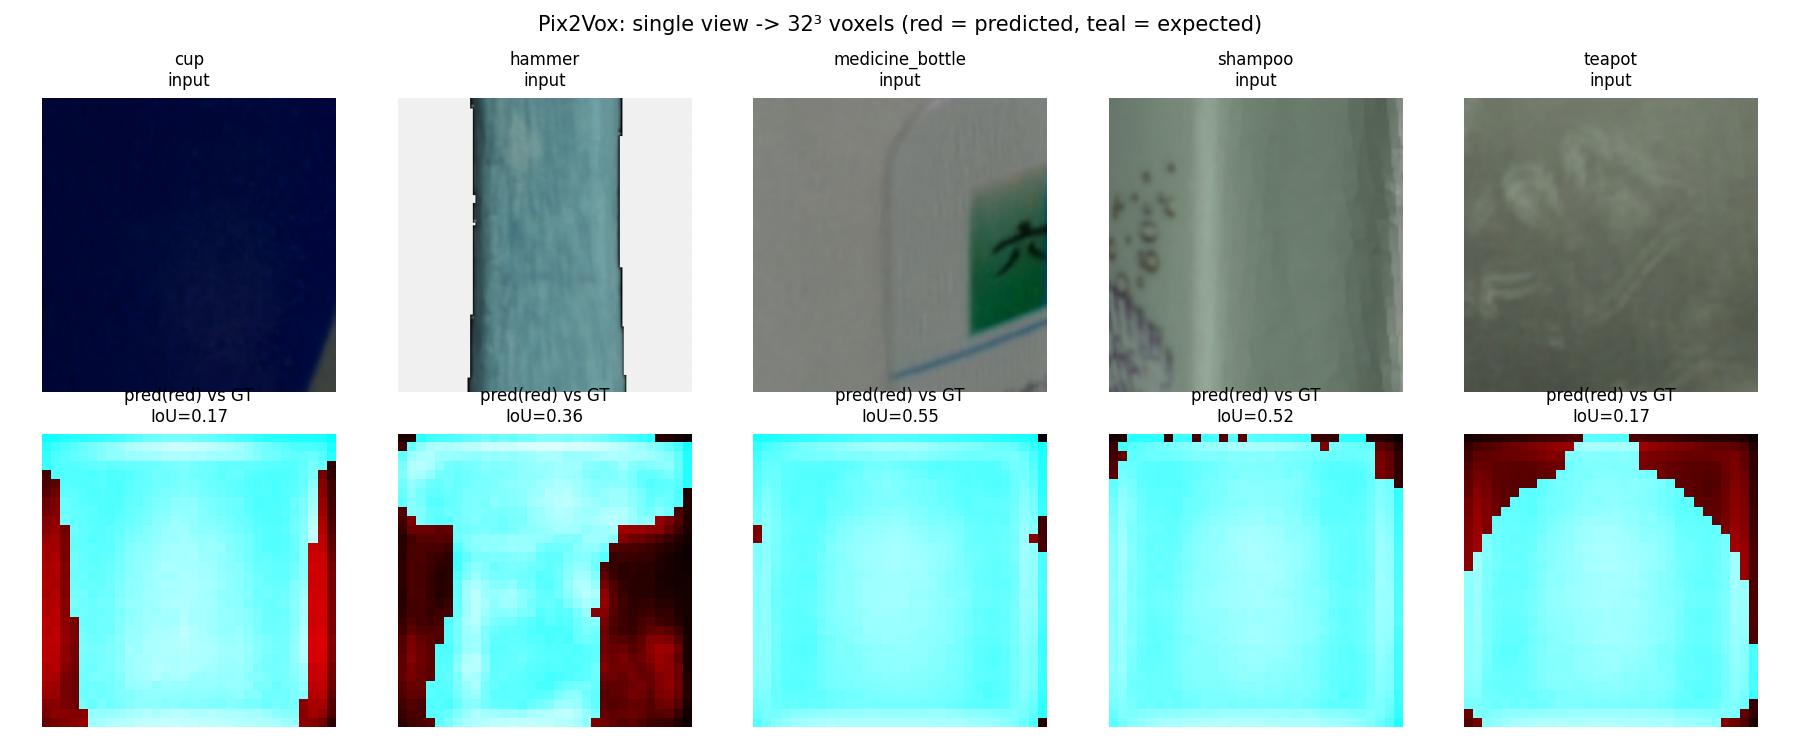

saved results/comparison/figures/qualitative/pix2vox_compare.png


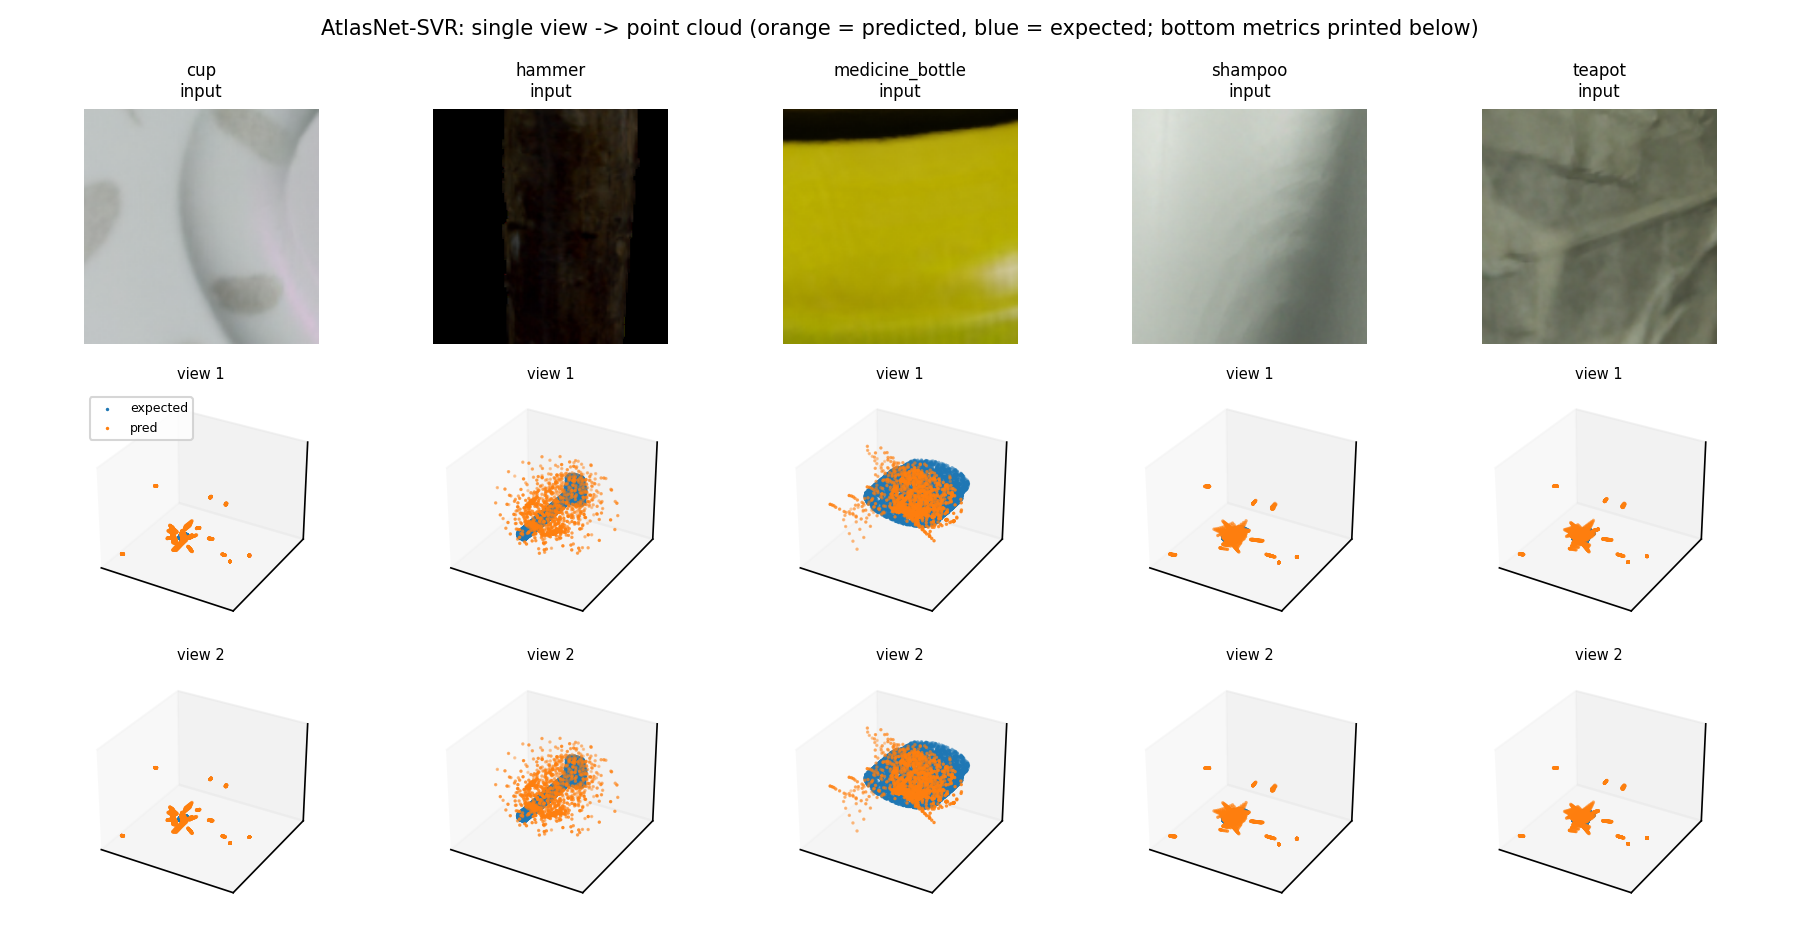

saved results/comparison/figures/qualitative/atlasnet_compare.png


,category,chamfer,fscore_tau0.01
0,cup,5.843052,0.000606
1,hammer,0.251758,0.004516
2,medicine_bottle,0.264806,0.002010
3,shampoo,1.595909,0.001823
4,teapot,2.187130,0.000910


In [15]:
def _max_proj(vol, axis):
    return vol.max(axis=axis).T  # [a,b] -> image with a on x


def _panels(axes, vol, color):
    projs = [("front xy", vol.max(axis=2).T), ("side zy", vol.max(axis=0).T)]
    for ax, (title, p) in zip(axes, projs):
        ax.imshow(p, cmap=color, origin="lower", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(title, fontsize=8)
        ax.axis("off")


QUAL = RESULTS / "qualitative"
QUAL_FIG = FIGDIR / "qualitative"
QUAL_FIG.mkdir(parents=True, exist_ok=True)

# ---- Pix2Vox: input | predicted | expected ----
p2v_qual = sorted((QUAL / "pix2vox").glob("*/metrics.json")) if (QUAL / "pix2vox").is_dir() else []
if p2v_qual:
    n = len(p2v_qual)
    fig, axes = plt.subplots(2, n, figsize=(2.4 * n, 5.0))
    axes = np.atleast_2d(axes)
    for j, mp in enumerate(p2v_qual):
        d = mp.parent
        m = json.loads(mp.read_text())
        pred, gt = np.load(d / "pred.npy"), np.load(d / "gt.npy")
        axes[0, j].imshow(plt.imread(d / "input.png"))
        axes[0, j].set_title(f"{m['category']}\ninput", fontsize=8)
        axes[0, j].axis("off")
        _panels(axes[1, j:j + 1].ravel(), np.zeros_like(gt), "Greys")  # placeholder guard
        # overlay pred (red) vs gt (blue-green) as RGB composite max-projection
        rgb = np.zeros(pred.shape[:2] + (3,), dtype=float)
        ov_pred = pred.max(axis=2).T
        ov_gt = gt.max(axis=2).T
        rgb[..., 0] = ov_pred
        rgb[..., 1] = ov_gt
        rgb[..., 2] = ov_gt
        axes[1, j].imshow(rgb, origin="lower", interpolation="nearest")
        axes[1, j].set_title(f"pred(red) vs GT\nIoU={m['iou_t0.3']:.2f}", fontsize=8)
        axes[1, j].axis("off")
    fig.suptitle("Pix2Vox: single view -> 32³ voxels (red = predicted, teal = expected)", fontsize=10)
    fig.tight_layout()
    fig.savefig(QUAL_FIG / "pix2vox_compare.png", dpi=150)
    plotting.show_saved(QUAL_FIG / "pix2vox_compare.png")
    print("saved", (QUAL_FIG / "pix2vox_compare.png").relative_to(ROOT))
else:
    print("no Pix2Vox qualitative artifacts (run make_qual_pix2vox.py)")

# ---- AtlasNet: input | predicted | expected, two viewpoints ----
atl_qual = sorted((QUAL / "atlasnet").glob("*/metrics.json")) if (QUAL / "atlasnet").is_dir() else []
if atl_qual:
    n = len(atl_qual)
    views = [(25, 20), (65, -60)]
    fig = plt.figure(figsize=(2.4 * n, 6.2))
    for j, mp in enumerate(atl_qual):
        d = mp.parent
        m = json.loads(mp.read_text())
        pred, gt = np.load(d / "pred.npy"), np.load(d / "gt.npy")
        ax0 = fig.add_subplot(3, n, j + 1)
        ax0.imshow(plt.imread(d / "input.png"))
        ax0.set_title(f"{m['category']}\ninput", fontsize=8)
        ax0.axis("off")
        for row, (elev, azim) in enumerate(views):
            ax = fig.add_subplot(3, n, (row + 1) * n + j + 1, projection="3d")
            ax.scatter(gt[:, 0], gt[:, 1], gt[:, 2], s=0.4, c="#1f77b4", label="expected")
            ax.scatter(pred[:, 0], pred[:, 1], pred[:, 2], s=0.4, c="#ff7f0e", label="pred")
            ax.set_title(f"view {row + 1}", fontsize=7)
            ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
            if row == 0 and j == 0:
                ax.legend(fontsize=6, loc="upper left")
        if j == 0:
            pass
    fig.suptitle("AtlasNet-SVR: single view -> point cloud (orange = predicted, blue = expected; bottom metrics printed below)", fontsize=10)
    fig.tight_layout()
    fig.savefig(QUAL_FIG / "atlasnet_compare.png", dpi=150)
    plotting.show_saved(QUAL_FIG / "atlasnet_compare.png")
    print("saved", (QUAL_FIG / "atlasnet_compare.png").relative_to(ROOT))
    qdf = pd.DataFrame([{**json.loads(p.read_text()),
                         "object": p.parent.name} for p in atl_qual])
    display(qdf[["category", "chamfer", "fscore_tau0.01"]])
else:
    print("no AtlasNet qualitative artifacts (run make_qual_atlasnet.py)")

### NeRF oracle: rendered held-out view vs expected

The oracle is trained on 20 posed views of the *same* object and reports on the
4 held-out views, so it is an upper bound on multi-view reconstruction quality —
not directly comparable to the single-view IoU / Chamfer numbers, which is why it
keeps its own metric (PSNR/SSIM).

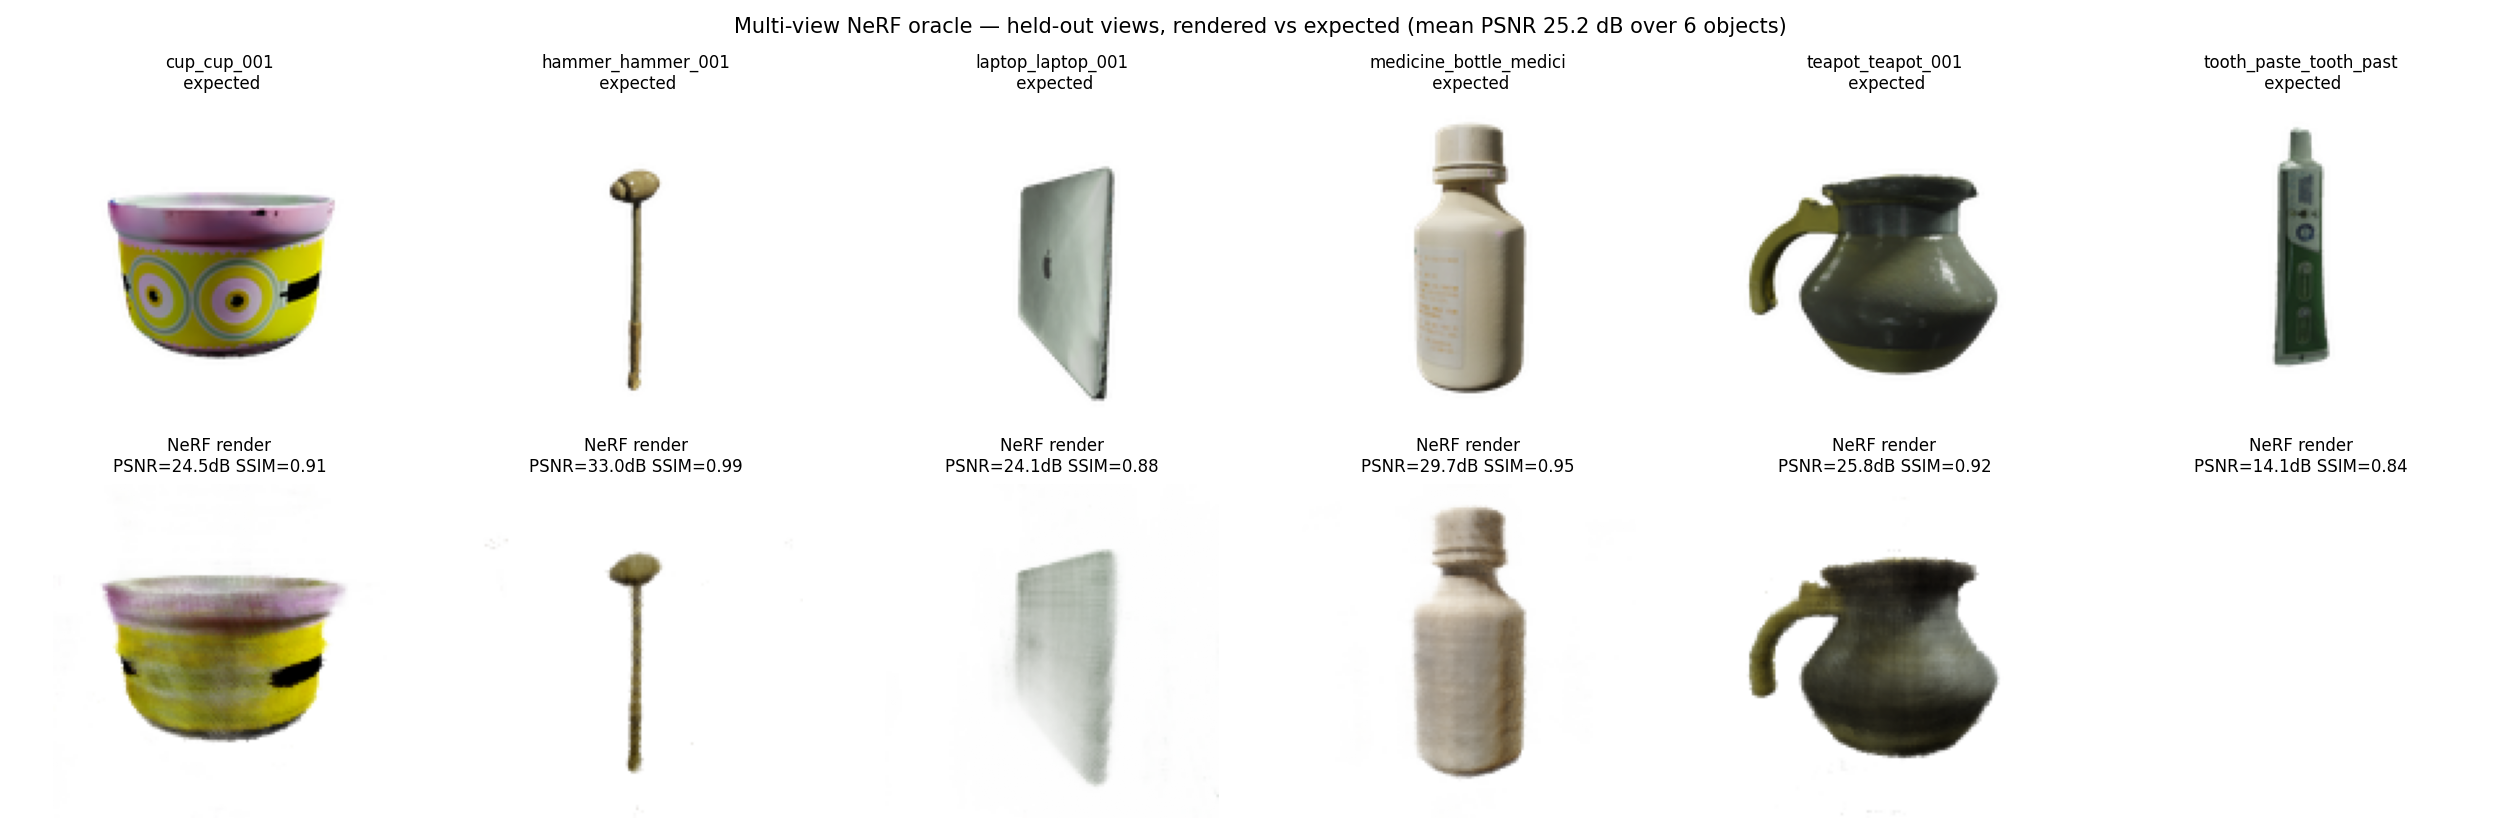

saved results/comparison/figures/qualitative/nerf_oracle.png


,object,psnr,ssim,n_test_views
1,hammer_hammer_001,32.98,0.993,4
3,medicine_bottle_medicine_bottle_001,29.67,0.953,4
4,teapot_teapot_001,25.82,0.915,4
0,cup_cup_001,24.54,0.910,4
2,laptop_laptop_001,24.10,0.884,4
5,tooth_paste_tooth_paste_001,14.08,0.844,4


In [16]:
oracle_runs = sorted(p for p in (RESULTS / "oracle").glob("*/summary.json")) \
    if (RESULTS / "oracle").is_dir() else []
if oracle_runs:
    osum = [json.loads(p.read_text()) for p in oracle_runs]
    n = len(osum)
    fig, axes = plt.subplots(2, n, figsize=(2.8 * n, 5.6))
    axes = np.atleast_2d(axes)
    for j, (s, p) in enumerate(zip(osum, oracle_runs)):
        d = p.parent
        axes[0, j].imshow(plt.imread(d / "gt.png"))
        axes[0, j].set_title(f"{s['object'][:22]}\n expected", fontsize=8)
        axes[0, j].axis("off")
        axes[1, j].imshow(plt.imread(d / "render.png"))
        axes[1, j].set_title(f"NeRF render\nPSNR={s['psnr']:.1f}dB SSIM={s['ssim']:.2f}", fontsize=8)
        axes[1, j].axis("off")
    mean_psnr = float(np.mean([s["psnr"] for s in osum]))
    fig.suptitle(f"Multi-view NeRF oracle — held-out views, rendered vs expected "
                 f"(mean PSNR {mean_psnr:.1f} dB over {n} objects)", fontsize=10)
    fig.tight_layout()
    out = QUAL_FIG / "nerf_oracle.png"
    fig.savefig(out, dpi=150)
    plotting.show_saved(out)
    print("saved", out.relative_to(ROOT))
    odf = pd.DataFrame([{"object": s["object"], "psnr": round(s["psnr"], 2),
                         "ssim": round(s["ssim"], 3), "n_test_views": s["n_test_views"]}
                        for s in osum]).sort_values("psnr", ascending=False)
    display(odf)
else:
    print("no oracle artifacts (run python multiview_nerf_oracle.py)")

## 6. Write the results index (`results/README.md`)

Keeps a human-readable record of every run and the generated figures.

In [17]:
lines = ["# Results index", "",
         "Auto-generated by `notebooks/dataset_analysis.ipynb`. Do not edit by hand.", "",
         "## Dataset", ""]
if df is not None and len(df):
    lines += [f"- categories: {len(df)}",
              f"- objects: {int(df['objects_pc'].sum())}",
              f"- images: {int(df['total_pngs'].sum())}",
              f"- structural issues: {len(issues)}", ""]
else:
    lines += ["- dataset not found", ""]

lines += ["## Runs", ""]
run_lines = [f"- **{r['model']}** `{r.get('run')}` — {r['metric']} = {r.get('headline')}"
             for r in comp_rows]
lines += run_lines if run_lines else ["- (none yet)"]
lines += ["", "## Figures", ""]
figs = sorted(FIGDIR.rglob("*.png"))
lines += ([f"- `{p.relative_to(ROOT)}`" for p in figs] if figs else ["- (none yet)"])

out_md = RESULTS / "README.md"
out_md.write_text("\n".join(lines) + "\n")
print("wrote", out_md.relative_to(ROOT))
print("\n".join(lines))

wrote results/README.md
# Results index

Auto-generated by `notebooks/dataset_analysis.ipynb`. Do not edit by hand.

## Dataset

- categories: 69
- objects: 1543
- images: 37017
- structural issues: 2

## Runs

- **Pix2Vox** `2026-09-25T01:10:43.513497` — IoU@t=0.3 = 0.3372
- **Pix2Vox** `2026-09-25T06:51:00.676358` — IoU@t=0.3 = 0.3374
- **Pix2Vox** `2026-09-25T16:25:17.351995` — IoU@t=0.2 = 0.3073
- **AtlasNet-SVR** `svr25` — F-score = 0.08792327493429183
- **AtlasNet-SVR** `svr25_150` — F-score = 0.07928681075572967
- **AtlasNet-SVR** `svr25_full` — F-score = 0.08173999842256308
- **NeRF-oracle (multi-view)** `sample-6` — PSNR (dB) = 25.199849005895018

## Figures

- `results/comparison/figures/objects_per_category.png`
- `results/comparison/figures/qualitative/atlasnet_compare.png`
- `results/comparison/figures/qualitative/nerf_oracle.png`
- `results/comparison/figures/qualitative/pix2vox_compare.png`


## 7. Summary

Run of this notebook produced the dataset report, the failure-point list, the
cleaning recommendations, and the results index. Re-run after every training
run or dataset change.